<a href="https://colab.research.google.com/github/hinojosaM/-machine_learning_homework2/blob/main/machine_learning_homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Importing our essential data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request

In [17]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
file_name = "car_fuel_efficiency_2026.csv"

# Download the file (similar to using wget in the terminal)
urllib.request.urlretrieve(url, file_name)

# Load the dataset into pandas
df_raw = pd.read_csv(file_name)

# Keep only the columns we actually need for this assignment
useful_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]
df = df_raw[useful_columns].copy()

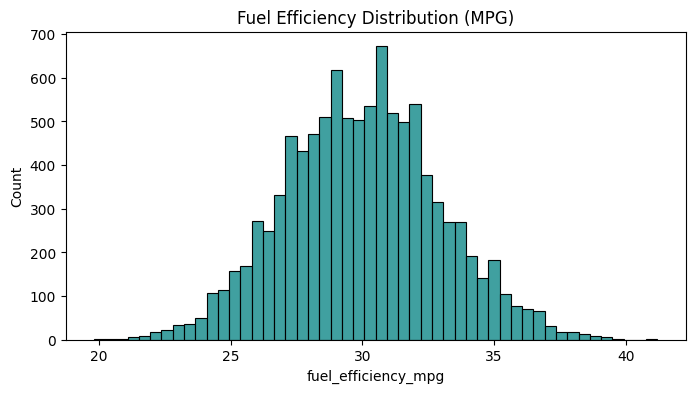

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(df['fuel_efficiency_mpg'], bins=50, color='teal')
plt.title('Fuel Efficiency Distribution (MPG)')
plt.show()


In [19]:
# Find which column has missing data
nulls = df.isnull().sum()
column_with_nulls = nulls[nulls > 0].index[0]
print(f"ANSWER Q1: The column with missing values is '{column_with_nulls}' (it has {nulls[column_with_nulls]} nulls).\n")

ANSWER Q1: The column with missing values is 'horsepower' (it has 877 nulls).



In [20]:
median_hp = df['horsepower'].median()
print(f" ANSWER Q2: The median for 'horsepower' is {median_hp}.\n")

 ANSWER Q2: The median for 'horsepower' is 254.0.



In [21]:
# HELPER FUNCTIONS: The math behind the magic
def train_linear_regression(X, y, r=0.0):
    # Add a column of ones for the bias term (w0)
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # X Transpose dot X (Gram matrix)
    XTX = X.T.dot(X)

    # Add regularization to the main diagonal (r)
    # If r=0, this is just standard linear regression.
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    # Inverse of XTX
    XTX_inv = np.linalg.inv(XTX)

    # Calculate the weights (w)
    w = XTX_inv.dot(X.T).dot(y)

    # Return the bias (w0) and the rest of the weights
    return w[0], w[1:]

def calculate_rmse(y_real, y_pred):
    # Mean Squared Error, then taking the square root
    error = y_pred - y_real
    mse = (error ** 2).mean()
    return np.sqrt(mse)

def prepare_and_split_data(full_df, seed):
    # Shuffle and split exactly as requested (60% / 20% / 20%)
    n = len(full_df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = full_df.iloc[idx[:n_train]].copy()
    df_val = full_df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = full_df.iloc[idx[n_train + n_val:]].copy()

    # Extract the target variable (y) and remove it from the feature sets (X)
    y_train = df_train.pop('fuel_efficiency_mpg').values
    y_val = df_val.pop('fuel_efficiency_mpg').values
    y_test = df_test.pop('fuel_efficiency_mpg').values

    return df_train, df_val, df_test, y_train, y_val, y_test

In [22]:
# Split using seed 42
df_train, df_val, df_test, y_train, y_val, y_test = prepare_and_split_data(df, seed=42)

# Calculate the mean ONLY using the training dataset
mean_hp = df_train['horsepower'].mean()

# Option A: Fill with 0
X_train_0 = df_train.fillna(0).values
X_val_0 = df_val.fillna(0).values
w_0_zero, w_zero = train_linear_regression(X_train_0, y_train)
y_pred_0 = w_0_zero + X_val_0.dot(w_zero)
rmse_with_zeros = calculate_rmse(y_val, y_pred_0)

# Option B: Fill with mean
X_train_mean = df_train.fillna(mean_hp).values
X_val_mean = df_val.fillna(mean_hp).values
w_0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w_0_mean + X_val_mean.dot(w_mean)
rmse_with_mean = calculate_rmse(y_val, y_pred_mean)

print("Q3 Results:")
print(f"  RMSE filling with 0:    {round(rmse_with_zeros, 3)}")
print(f"  RMSE filling with mean: {round(rmse_with_mean, 3)}")

Q3 Results:
  RMSE filling with 0:    2.205
  RMSE filling with mean: 2.202


In [23]:
# QUESTION 4: Regularization (Finding the best "r")
# Using the dataset filled with 0 from the previous question
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
best_r = None
best_rmse = float('inf')

print("Q4 Results:")
for r in r_values:
    w_0_reg, w_reg = train_linear_regression(X_train_0, y_train, r=r)
    y_pred_reg = w_0_reg + X_val_0.dot(w_reg)
    current_rmse = calculate_rmse(y_val, y_pred_reg)
    rounded_rmse = round(current_rmse, 4)

    print(f"  For r={r:<5} -> RMSE: {rounded_rmse}")

    if rounded_rmse < best_rmse:
        best_rmse = rounded_rmse
        best_r = r

print(f" ANSWER Q4: The 'r' that yields the best RMSE is {best_r} (with an RMSE of {best_rmse}).\n")

Q4 Results:
  For r=0     -> RMSE: 2.2053
  For r=0.01  -> RMSE: 2.2058
  For r=0.1   -> RMSE: 2.2241
  For r=1     -> RMSE: 2.3492
  For r=5     -> RMSE: 2.4094
  For r=10    -> RMSE: 2.4195
  For r=100   -> RMSE: 2.4292
 ANSWER Q4: The 'r' that yields the best RMSE is 0 (with an RMSE of 2.2053).



In [24]:
# QUESTION 5: Seed Impact (Standard Deviation)
# ------------------------------------------------------------------------------
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_list = []

for s in seeds:
    df_t, df_v, _, yt, yv, _ = prepare_and_split_data(df, seed=s)

    # Fill with 0
    X_t_0 = df_t.fillna(0).values
    X_v_0 = df_v.fillna(0).values

    # Train without regularization (r=0)
    w_0_s, w_s = train_linear_regression(X_t_0, yt, r=0)
    y_p_s = w_0_s + X_v_0.dot(w_s)

    # Store the RMSE
    rmse_list.append(calculate_rmse(yv, y_p_s))

# Calculate the standard deviation of the scores
std_rmse = np.std(rmse_list)
print(f" ANSWER Q5: The standard deviation of all scores is {round(std_rmse, 3)}.\n")

 ANSWER Q5: The standard deviation of all scores is 0.029.



In [25]:
# QUESTION 6: Final Training and Testing
# Use seed 9
df_t9, df_v9, df_test9, yt9, yv9, ytest9 = prepare_and_split_data(df, seed=9)

# Combine Train and Validation into a single dataset
df_train_full = pd.concat([df_t9, df_v9])
y_train_full = np.concatenate([yt9, yv9])

# Fill nulls with 0
X_train_full = df_train_full.fillna(0).values
X_test = df_test9.fillna(0).values

# Train with r=0.001
w_0_final, w_final = train_linear_regression(X_train_full, y_train_full, r=0.001)

# Evaluate on the TEST set
y_pred_test = w_0_final + X_test.dot(w_final)
final_test_rmse = calculate_rmse(ytest9, y_pred_test)

print(f" ANSWER Q6: The RMSE on the test dataset is {round(final_test_rmse, 3)}.")


 ANSWER Q6: The RMSE on the test dataset is 2.236.
